# Predictive Modeling Using Machine Learning
## Classification with Confusion Matrix, ROC & AUC

This project follows the approach from the referenced tutorial ("Confusion matrix, ROC and AUC in
machine learning"), which evaluates a **classifier** — confusion matrices and ROC/AUC curves are
classification metrics, so the task here is to predict a *category*, not a continuous number.

**Dataset:** the Breast Cancer Wisconsin (Diagnostic) dataset — 569 tumor samples, 30 numeric
features measured from digitized images of a breast mass (radius, texture, perimeter, area,
smoothness, etc.), with a binary target: **malignant** or **benign**. It ships with scikit-learn,
so it's fully reproducible with no external download.

**Goal:** train and compare classifiers, then evaluate them properly with confusion matrices,
ROC curves, and AUC scores — exactly what the tutorial covers.

**Models compared:** Logistic Regression (the linear baseline classifier — the classification
counterpart to Linear Regression), Decision Tree, and Random Forest.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_curve, roc_auc_score, accuracy_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"] = pd.Categorical.from_codes(data.target, data.target_names)
print("Shape:", df.shape)
df.head()


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 1. Explore the Data

In [2]:
df.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [3]:
print("Missing values:", df.isnull().values.sum())
print()
print("Class balance:")
print(df["diagnosis"].value_counts())


Missing values: 0

Class balance:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


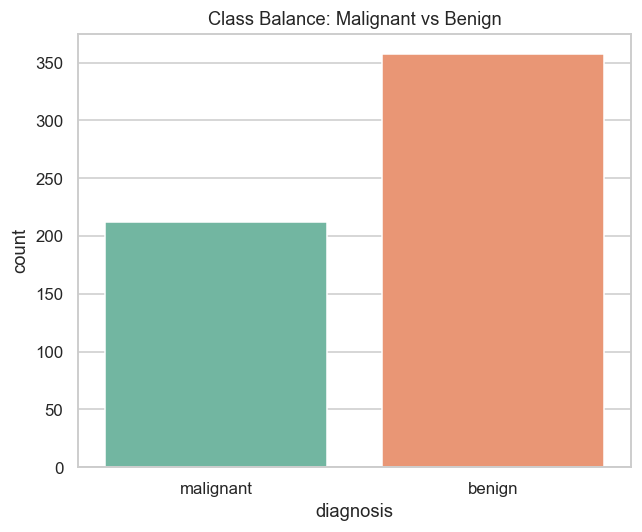

In [4]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="diagnosis", hue="diagnosis", palette="Set2", legend=False)
plt.title("Class Balance: Malignant vs Benign")
plt.tight_layout()
plt.show()


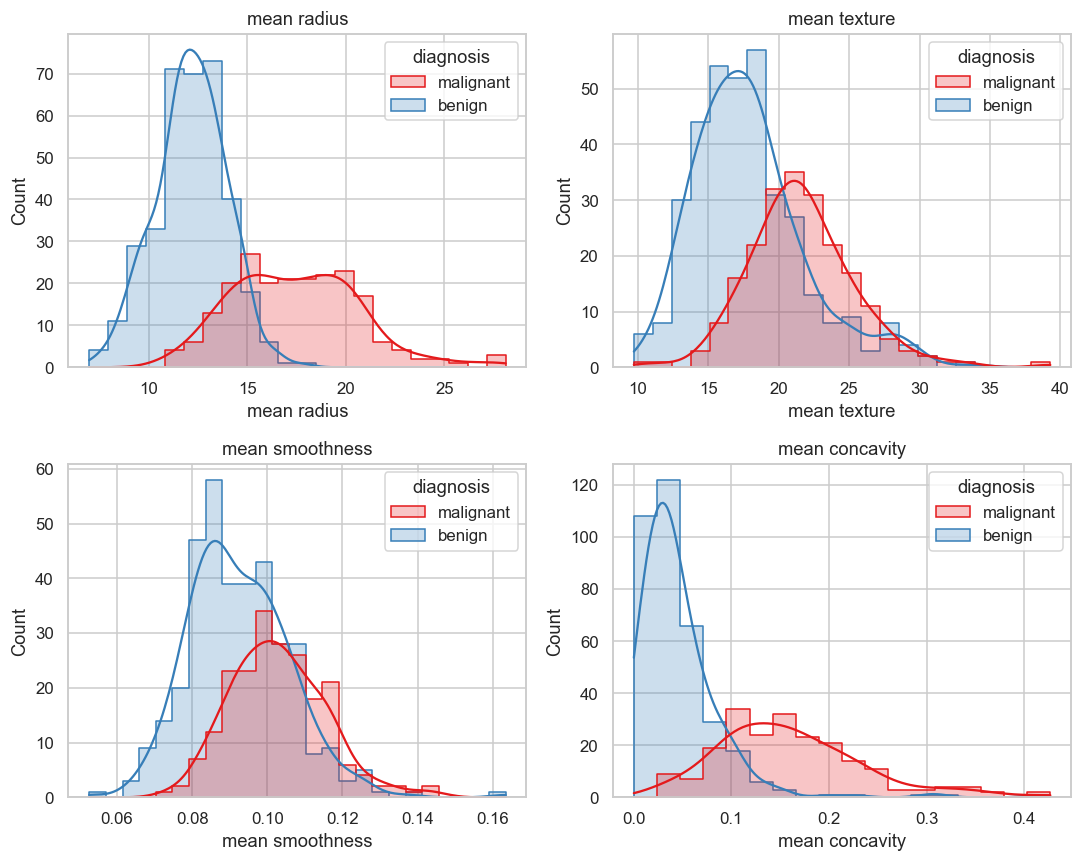

In [5]:
key_features = ["mean radius", "mean texture", "mean smoothness", "mean concavity"]
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for ax, feat in zip(axes.ravel(), key_features):
    sns.histplot(data=df, x=feat, hue="diagnosis", kde=True, ax=ax, palette="Set1", element="step")
    ax.set_title(feat)
plt.tight_layout()
plt.show()


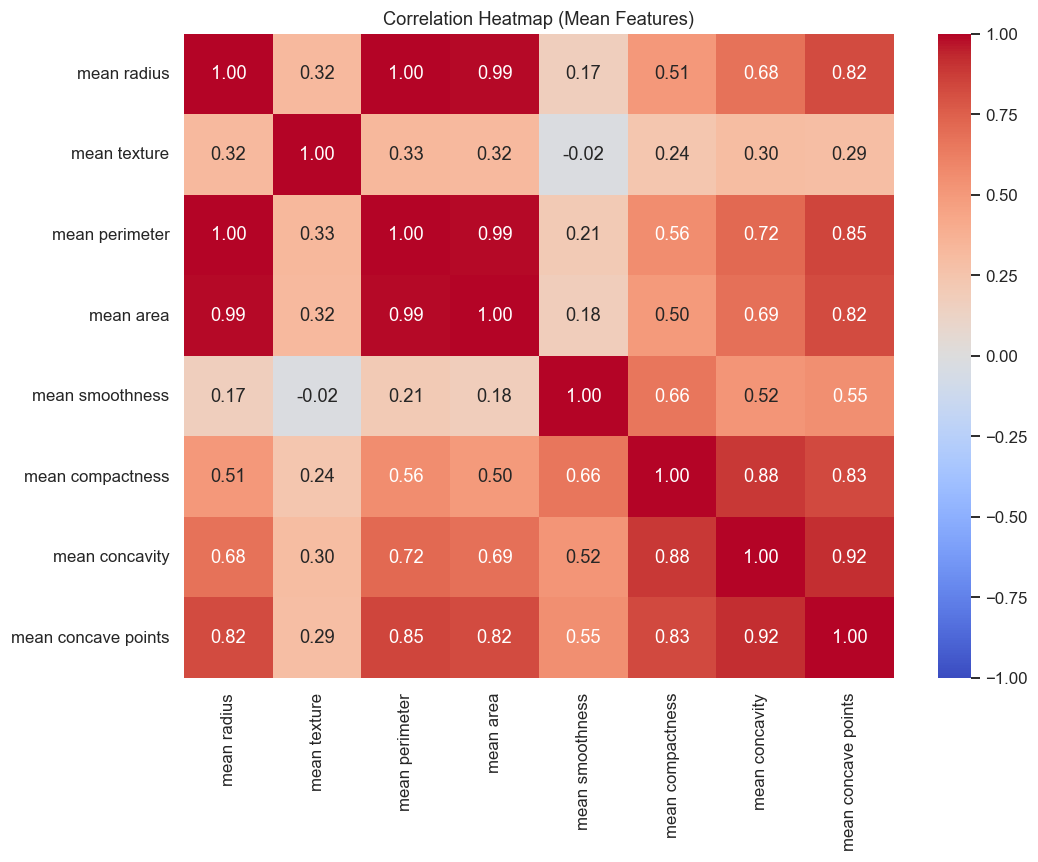

In [6]:
plt.figure(figsize=(10,8))
subset = ["mean radius","mean texture","mean perimeter","mean area","mean smoothness",
          "mean compactness","mean concavity","mean concave points"]
sns.heatmap(df[subset].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Mean Features)")
plt.tight_layout()
plt.show()


## 2. Train / Test Split & Scaling

Logistic Regression is sensitive to feature scale, so we standardize the features. Tree-based
models don't need this, but it doesn't hurt them either, so we apply it uniformly for simplicity.


In [7]:
X = df[data.feature_names]
y = data.target  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training rows: {len(X_train)}  |  Test rows: {len(X_test)}")


Training rows: 455  |  Test rows: 114


## 3. Train Three Classifiers

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
}

fitted = {}
probs = {}
preds = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds[name] = model.predict(X_test_scaled)
    probs[name] = model.predict_proba(X_test_scaled)[:, 1]
    fitted[name] = model

accuracy_table = pd.Series({name: accuracy_score(y_test, preds[name]) for name in models}).sort_values(ascending=False)
accuracy_table.to_frame("Accuracy")


,Accuracy
Logistic Regression,0.982456
Random Forest,0.947368
Decision Tree,0.921053


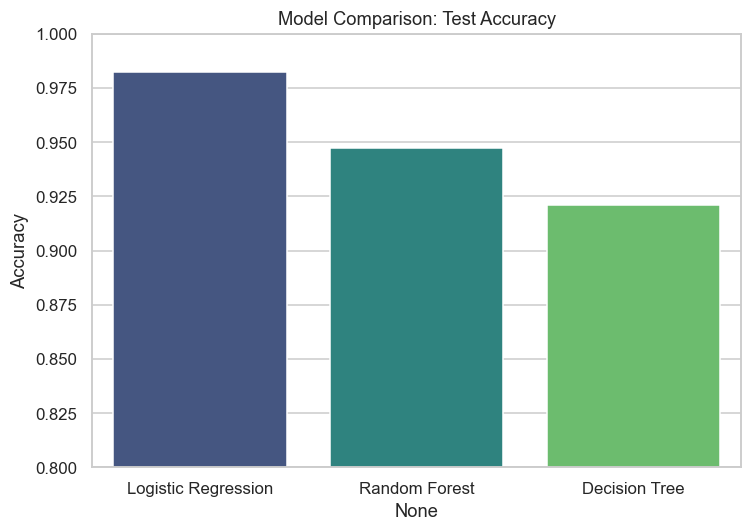

In [9]:
plt.figure(figsize=(7,5))
sns.barplot(x=accuracy_table.index, y=accuracy_table.values, hue=accuracy_table.index, palette="viridis", legend=False)
plt.title("Model Comparison: Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


## 4. Confusion Matrices

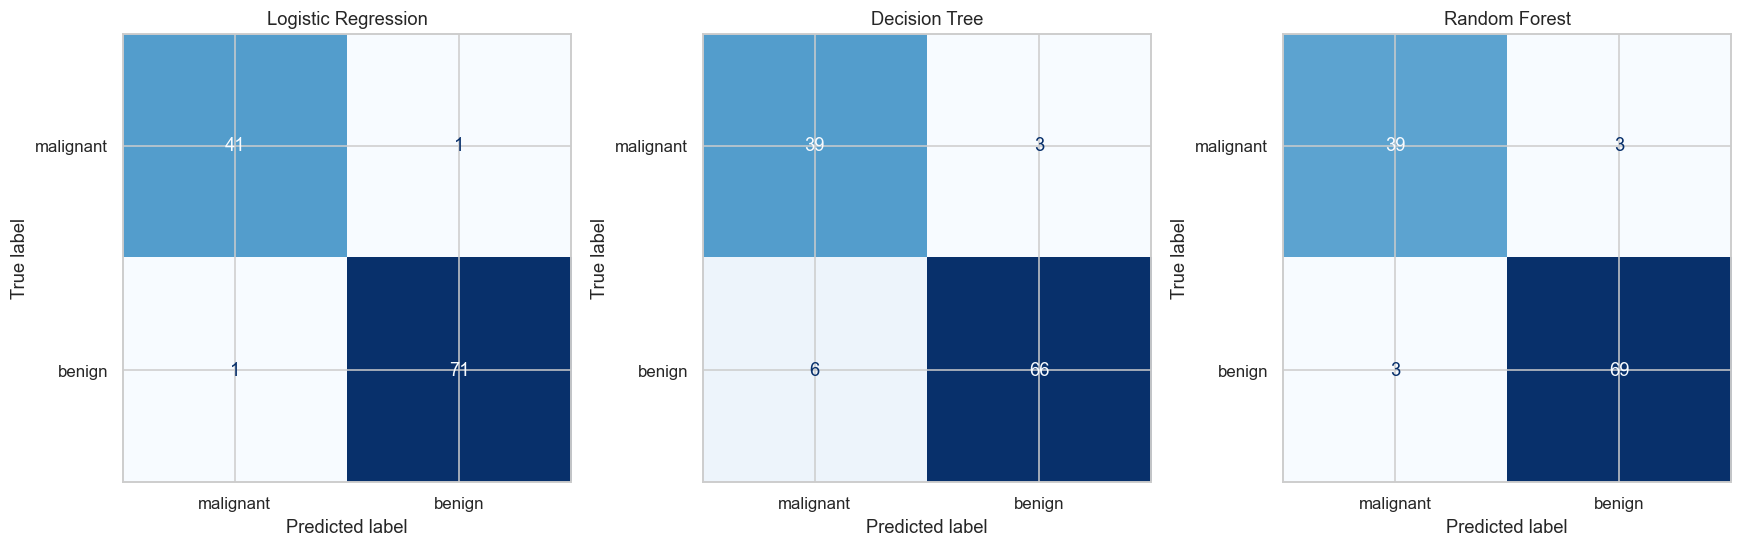

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [11]:
best_name = accuracy_table.index[0]
print(f"Detailed classification report for the best model ({best_name}):\n")
print(classification_report(y_test, preds[best_name], target_names=data.target_names))


Detailed classification report for the best model (Logistic Regression):

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 5. ROC Curves & AUC

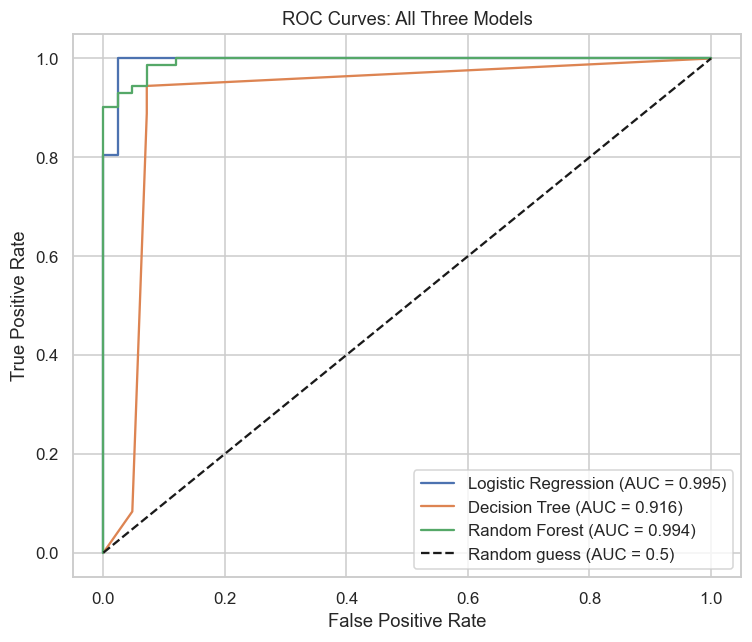

In [12]:
plt.figure(figsize=(7,6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    auc = roc_auc_score(y_test, probs[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: All Three Models")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
auc_table = pd.Series({name: roc_auc_score(y_test, probs[name]) for name in models}).sort_values(ascending=False)
auc_table.to_frame("AUC")


,AUC
Logistic Regression,0.995370
Random Forest,0.994048
Decision Tree,0.916336


## 6. What Drives the Diagnosis? (Feature Importance)

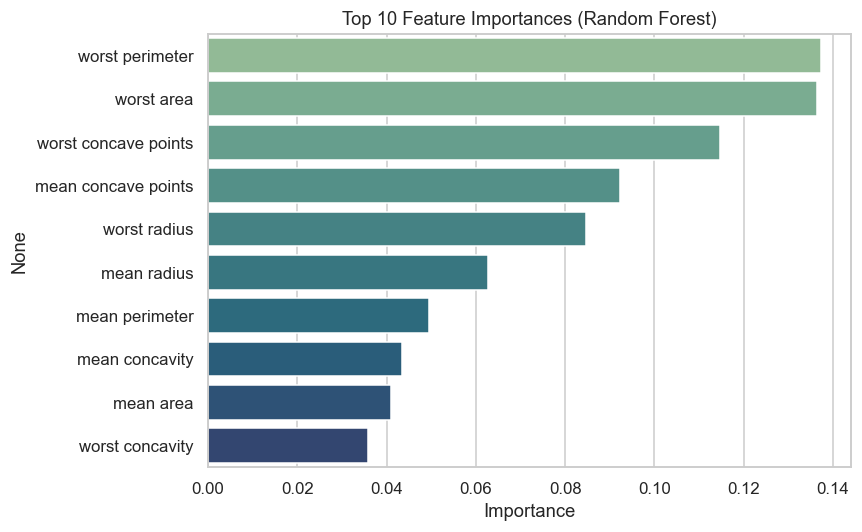

In [14]:
rf = fitted["Random Forest"]
fi = pd.Series(rf.feature_importances_, index=data.feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=fi.values, y=fi.index, hue=fi.index, palette="crest", legend=False)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 7. Key Findings

- **Accuracy:** all three models score highly on this dataset (it's a well-separated, well-known
  benchmark dataset), but the table above shows which model edged out the others on the held-out
  test set.
- **Confusion matrices** show where each model's mistakes concentrate — in a medical diagnosis
  context, false negatives (predicting benign when the tumor is actually malignant) are the more
  dangerous error type, so it's worth checking the bottom-left cell of each matrix specifically,
  not just overall accuracy.
- **ROC/AUC:** AUC summarizes a model's ability to separate the two classes across every possible
  decision threshold, not just the default 0.5 cutoff — a model can have a high AUC even if its
  default-threshold accuracy looks only average, which is why both metrics are reported together.
- **Feature importance:** a small number of features (typically related to cell concavity and
  area) drive most of the Random Forest's decisions, consistent with what's clinically known about
  tumor malignancy indicators.

## Tech Stack
- **Pandas / NumPy** — data loading and manipulation
- **Scikit-learn** — train/test split, scaling, Logistic Regression, Decision Tree, Random Forest,
  confusion matrix, ROC curve, and AUC score
- **Matplotlib / Seaborn** — visualization

## Files in this repo
- `Classification_Confusion_Matrix_ROC_AUC_Project.ipynb` — this notebook (dataset is loaded
  directly from scikit-learn, so no separate CSV is needed)
